In [ ]:
#@title Prep { display-mode: "form" }
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

print("TensorFlow version: {}".format(tf.__version__))

# Load data
def load_cifar10():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
  y_train_cifar = y_train_cifar.squeeze()
  y_test_cifar = y_test_cifar.squeeze()
  return (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar)

# CIFAR100 classes
idx_to_class = ['background', 'car', 'truck']

# Construct vehicle dataset from CIFAR10
def construct_vehicle_dataset(data, labels, images_per_class, label_car=1, label_truck=9):
  mask_car = labels == label_car
  mask_truck = labels == label_truck

  mask_vehicles = mask_car | mask_truck
  mask_background = np.invert(mask_vehicles)

  data_car = data[mask_car]
  data_truck = data[mask_truck]
  data_background = data[mask_background][:images_per_class]

  new_data = np.vstack((data_background, data_car, data_truck))
  new_labels = np.repeat(np.array([0, 1, 2]), images_per_class, axis=0)

  return new_data, new_labels

def load_vehicle_dataset():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = load_cifar10()
  X_train, y_train = construct_vehicle_dataset(X_train_cifar, y_train_cifar, 5000)
  X_test, y_test = construct_vehicle_dataset(X_test_cifar, y_test_cifar, 1000)
  return (X_train, y_train), (X_test, y_test)

# Helper functions

# plotting
def plot_one_image(data, labels = [], index = None, image_shape = None):
  '''
  if data is a single image, display that image

  if data is a 4d stack of images, display that image
  '''
  ### cv2.imshow('image', data)
  num_dims   = len(data.shape)
  num_labels = len(labels)
  if image_shape is not None:
    target_shape = image_shape
  else:
    target_shape = (32, 32, 3)
  # reshape data if necessary
  if num_dims == 1:
    data = data.reshape(target_shape)
  if num_dims == 2:
    data = data.reshape(np.vstack[-1, image_shape])
  num_dims   = len(data.shape)

  # check if single or multiple images
  if num_dims == 3:
    if num_labels > 1:
      print('Multiple labels does not make sense for single image.')
      return

    label = labels
    if num_labels == 0:
      label = ''
    image = data

  if num_dims == 4:
    if index is not None:
      image = data[index, :]
      label = labels[index]

    else:
      print("Images were provided as a list, but the index variable was left blank")

  # plot image of interest

  # plot image of interest
  print('Label: %s'%label)
  plt.imshow(image)
  plt.show()

def model_to_string(model):
  import re
  stringlist = []
  model.summary(print_fn=lambda x: stringlist.append(x))
  sms = "\n".join(stringlist)
  sms = re.sub('_\d\d\d','', sms)
  sms = re.sub('_\d\d','', sms)
  sms = re.sub('_\d','', sms)
  return sms

def normalize(data):
  # CIFAR100 mean (0.4914, 0.4822, 0.4465) std (0.2023, 0.1994, 0.2010)
  return (data/255-np.array((0.4914, 0.4822, 0.4465))) / np.array((0.2023, 0.1994, 0.2010))

def label_to_onehot(labels):
  final_labels = np.zeros((len(labels), 3))
  for i in range(len(labels)):
    label = labels[i]
    if label == 0:
      final_labels[i,:] = np.array([1, 0, 0])
    if label == 1:
      final_labels[i,:] = np.array([0, 1, 0])
    if label == 2:
      final_labels[i,:] = np.array([0, 0, 1])
  return final_labels

def plot_acc(history, ax = None, xlabel = 'Epoch #'):
  # i'm sorry for this function's code. i am so sorry.
  history = history.history
  history.update({'epoch':list(range(len(history['val_accuracy'])))})
  history = pd.DataFrame.from_dict(history)

  best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

  if not ax:
    f, ax = plt.subplots(1,1)
  sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
  sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
  ax.axhline(0.333, linestyle = '--',color='red', label = 'Chance')
  ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
  ax.legend(loc = 3)
  ax.set_ylim([0.01, 1])

  ax.set_xlabel(xlabel)
  ax.set_ylabel('Accuracy (Fraction)')

  plt.show()

<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:100: SyntaxWarning: invalid escape sequence '\d'
<>:101: SyntaxWarning: invalid escape sequence '\d'
<>:99: SyntaxWarning: invalid escape sequence '\d'
<>:100: SyntaxWarning: invalid escape sequence '\d'
<>:101: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_484/1680552000.py:99: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d\d\d','', sms)
/tmp/ipykernel_484/1680552000.py:100: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d\d','', sms)
/tmp/ipykernel_484/1680552000.py:101: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d','', sms)


In [ ]:
(X_train, y_train), (X_test, y_test) = load_vehicle_dataset()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


testing

In [ ]:
print('Our labels are stored as %s in Python' % type(y_train))
print('The label vector of the training set has dimensions of (%d, )' % y_train.shape)
print('The label vector of the test set has dimensions of (%d, )' % y_test.shape)

Our labels are stored as <class 'numpy.ndarray'> in Python
The label vector of the training set has dimensions of (15000, )
The label vector of the test set has dimensions of (3000, )


In [ ]:
for idx,value in enumerate(idx_to_class):
  print(idx, value)

0 background
1 car
2 truck


In [1]:
import collections
counter1 = collections.Counter(y_train)
print(counter1)
counter2 = collections.Counter(y_test)
print(counter2)

NameError: name 'y_train' is not defined

In [ ]:
print(X_train.shape)
print(X_test.shape)

(15000, 32, 32, 3)
(3000, 32, 32, 3)


NN

In [ ]:
#tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras import optimizers

In [ ]:
model_1 = Sequential()
model_1.add(Dense(4, input_shape=(3,), activation = 'relu'))
model_1.add(Dense(2, activation = 'softmax'))
model_1.compile(loss= 'categorical_crossentropy',
                optimizer= 'adam',
                metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1_answer = Sequential()
model_1_answer.add(Dense(4, input_shape = (3,), activation = 'relu'))
model_1_answer.add(Dense(2, activation = 'softmax'))
model_1_answer.compile(loss='categorical_crossentropy',
                       optimizer = 'adam',
                       metrics = ['accuracy'])

if model_to_string(model_1) == model_to_string(model_1_answer):
  print('Model worked')
else:
  print('Check again')

Please check your code again!


add layers

In [ ]:
perceptron = Sequential()
### FILL IN YOUR CODE HERE
perceptron.add(Flatten(input_shape = (32,32,3)))
perceptron.add(Dense(128, activation = 'relu'))
perceptron.add(Dense(100, activation = 'relu'))
perceptron.add(Dense(100, activation = 'relu'))
perceptron.add(Dense(100, activation = 'relu'))
perceptron.add(Dense(50, activation = 'relu'))
perceptron.add(Dense(50, activation = 'relu'))
perceptron.add(Dense(50, activation = 'relu'))
perceptron.add(Dense(50, activation = 'relu'))
perceptron.add(Dense(3, activation = 'softmax'))
perceptron.compile(loss= 'categorical_crossentropy',
                optimizer= optimizers.SGD(learning_rate=1e-3, momentum=0.9),
                metrics=['accuracy'])
### END CODE

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NameError: name 'dropout' is not defined

In [ ]:
#@title Run this to test if your model is right! { display-mode: "form" }
perceptron_answer = Sequential()
perceptron_answer.add(Flatten(input_shape = (32, 32, 3)))
perceptron_answer.add(Dense(units = 128, activation = 'relu'))
perceptron_answer.add(Dense(units = 3, activation = 'softmax'))

perceptron_answer.compile(loss='categorical_crossentropy',
                          optimizer=optimizers.SGD(learning_rate=1e-3, momentum=0.9),
                          metrics=['accuracy'])

if model_to_string(perceptron) == model_to_string(perceptron_answer):
  print('Model worked')
else:
  print('Check again')

Please check your code again!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# define monitor.
monitor = ModelCheckpoint('./model.keras', monitor='val_loss', verbose=0, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)

y_train_onehot = label_to_onehot(y_train)
y_test_onehot = label_to_onehot(y_test)

history = perceptron.fit(X_train_norm, y_train_onehot, epochs = 20, validation_data = (X_test_norm, y_test_onehot), shuffle = True, callbacks = [monitor])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4749 - loss: 1.0230 - val_accuracy: 0.6397 - val_loss: 0.8138
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6732 - loss: 0.7723 - val_accuracy: 0.6863 - val_loss: 0.7366
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7205 - loss: 0.6784 - val_accuracy: 0.6990 - val_loss: 0.7139
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7484 - loss: 0.6094 - val_accuracy: 0.7090 - val_loss: 0.6861
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7822 - loss: 0.5502 - val_accuracy: 0.7137 - val_loss: 0.6880
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8059 - loss: 0.4974 - val_accuracy: 0.7103 - val_loss: 0.7060
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8300 - loss: 0.4447 - val_accuracy: 0.6987 - val_loss: 0.7837
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8413 - loss: 0.4166 - val_accuracy: 0.

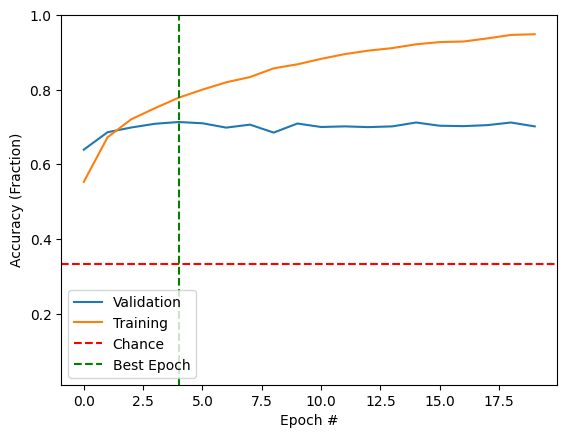

In [ ]:
### plot
plot_acc(history)


confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  print("Plotting the Confusion Matrix")

  labels = ["Background","Car","Truck"]
  df_cm = pd.DataFrame(cm, index=labels, columns=labels)
  fig = plt.figure(figsize=(7,6))
  res = sns.heatmap(df_cm, annot=True, cmap='YlGnBu', fmt='g')

  plt.yticks([0.5,1.5,2.5], labels, va='center')
  plt.title('Confusion Matrix')
  plt.ylabel('True Label')
  plt.xlabel('Predicted Label')
  plt.show()
  plt.close()

pred_probs = perceptron.predict(X_test_norm)
y_pred = pred_probs.argmax(axis = -1)
y_true = y_test_onehot.argmax(axis = -1)

print(accuracy_score(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
0.0
Plotting the Confusion Matrix


ValueError: Shape of passed values is (36, 36), indices imply (3, 3)

In [2]:
#@title Prep 2 { display-mode: "form" }
!pip install scikeras > /dev/null

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape, Dense, Conv2D, GlobalAveragePooling2D
from scikeras.wrappers import KerasClassifier
import tensorflow.keras.optimizers as optimizers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, DenseNet121

from PIL import Image
import gdown
from IPython import display

!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20%20Object%20Detection%20(Autonomous%20Vehicles)/image-2.jpg"
!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20%20Object%20Detection%20(Autonomous%20Vehicles)/image2.jpg"
!wget -q --show-progress "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20%20Object%20Detection%20(Autonomous%20Vehicles)/sliding.gif.png"

# Show sliding windows
def show_sliding_window():
  return display.Image(filename="sliding.gif.png")

# Construct vehicle dataset
label_car = 1
label_truck = 9

# Load data
def load_cifar10():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
  y_train_cifar = y_train_cifar.squeeze()
  y_test_cifar = y_test_cifar.squeeze()
  return (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar)

# CIFAR100 classes
idx_to_class = ['background', 'car', 'truck']

# Construct vehicle dataset from CIFAR10
def construct_vehicle_dataset(data, labels, images_per_class, label_car=1, label_truck=9):
  mask_car = labels == label_car
  mask_truck = labels == label_truck

  mask_vehicles = mask_car | mask_truck
  mask_background = np.invert(mask_vehicles)

  data_car = data[mask_car]
  data_truck = data[mask_truck]
  data_background = data[mask_background][:images_per_class]

  new_data = np.vstack((data_background, data_car, data_truck))
  new_labels = np.repeat(np.array([0, 1, 2]), images_per_class, axis=0)

  return new_data, new_labels

def load_vehicle_dataset():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = load_cifar10()
  X_train, y_train = construct_vehicle_dataset(X_train_cifar, y_train_cifar, 5000)
  X_test, y_test = construct_vehicle_dataset(X_test_cifar, y_test_cifar, 1000)
  return (X_train, y_train), (X_test, y_test)

# plotting
def plot_one_image(data, labels = [], index = None, image_shape = None, fig_size=None):
  '''
  if data is a single image, display that image

  if data is a 4d stack of images, display that image
  '''
  ### cv2.imshow('image', data)
  num_dims   = len(data.shape)
  num_labels = len(labels)
  if image_shape is not None:
    target_shape = image_shape
  else:
    target_shape = (32, 32, 3)
  # reshape data if necessary
  if num_dims == 1:
    data = data.reshape(target_shape)
  if num_dims == 2:
    data = data.reshape(np.vstack[-1, image_shape])
  num_dims   = len(data.shape)

  # check if single or multiple images
  if num_dims == 3:
    if num_labels > 1:
      print('Multiple labels does not make sense for single image.')
      return

    label = labels
    if num_labels == 0:
      label = ''
    image = data

  if num_dims == 4:
    image = data[index, :]
    label = labels[index]

  # plot image of interest
  print('Label: %s'%label)
  if fig_size is not None:
    plt.figure(figsize=fig_size)
  plt.imshow(image)
  plt.show()

def model_to_string(model):
  import re
  stringlist = []
  model.summary(print_fn=lambda x: stringlist.append(x))
  sms = "\n".join(stringlist)
  sms = re.sub('_\d\d\d','', sms)
  sms = re.sub('_\d\d','', sms)
  sms = re.sub('_\d','', sms)
  return sms

def normalize(data):
  # CIFAR100 mean (0.4914, 0.4822, 0.4465) std (0.2023, 0.1994, 0.2010)
  return (data/255-np.array((0.4914, 0.4822, 0.4465))) / np.array((0.2023, 0.1994, 0.2010))

def label_to_onehot(labels):
  final_labels = np.zeros((len(labels), 3))
  for i in range(len(labels)):
    label = labels[i]
    if label == 0:
      final_labels[i,:] = np.array([1, 0, 0])
    if label == 1:
      final_labels[i,:] = np.array([0, 1, 0])
    if label == 2:
      final_labels[i,:] = np.array([0, 0, 1])
  return final_labels

def plot_acc(history, ax = None, xlabel = 'Epoch #'):
  # i'm sorry for this function's code. i am so sorry.
  history = history.history
  history.update({'epoch':list(range(len(history['val_accuracy'])))})
  history = pd.DataFrame.from_dict(history)

  best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

  if not ax:
    f, ax = plt.subplots(1,1)
  sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
  sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
  ax.axhline(0.333, linestyle = '--',color='red', label = 'Chance')
  ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
  ax.legend(loc = 1)
  ax.set_ylim([0.01, 1])

  ax.set_xlabel(xlabel)
  ax.set_ylabel('Accuracy (Fraction)')

  plt.show()


def TransferClassifier_func(name, nn_params, trainable = True):
  expert_dict = {'VGG16': VGG16,
                  'VGG19': VGG19,
                  'ResNet50':ResNet50,
                  'DenseNet121':DenseNet121}

  expert_conv = expert_dict[name](weights = 'imagenet',
                                            include_top = False,
                                            input_shape = nn_params['input_shape'])
  for layer in expert_conv.layers:
    layer.trainable = trainable

  expert_model = Sequential()
  expert_model.add(expert_conv)
  expert_model.add(GlobalAveragePooling2D())

  expert_model.add(Dense(128, activation = 'relu'))
  expert_model.add(Dropout(0.3))

  expert_model.add(Dense(64, activation = 'relu'))

  expert_model.add(Dense(nn_params['output_neurons'], activation = nn_params['output_activation']))

  expert_model.compile(loss = nn_params['loss'],
                optimizer = optimizers.SGD(learning_rate=nn_params['learning_rate'], momentum=nn_params['momentum']),
                metrics=['accuracy'])

  return expert_model

# neural net parameters
image_shape          = (32, 32, 3)
nn_params = {}
nn_params['input_shape']       = image_shape
nn_params['output_neurons']    = 3
nn_params['loss']              = 'categorical_crossentropy'
nn_params['output_activation'] = 'softmax'
nn_params['learning_rate'] = 1e-3
nn_params['momentum'] = 0.9

TransferClassifier  = lambda name: TransferClassifier_func(name = name, nn_params = nn_params);

<>:115: SyntaxWarning: invalid escape sequence '\d'
<>:116: SyntaxWarning: invalid escape sequence '\d'
<>:117: SyntaxWarning: invalid escape sequence '\d'
<>:115: SyntaxWarning: invalid escape sequence '\d'
<>:116: SyntaxWarning: invalid escape sequence '\d'
<>:117: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1072/3191301380.py:115: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d\d\d','', sms)
/tmp/ipykernel_1072/3191301380.py:116: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d\d','', sms)
/tmp/ipykernel_1072/3191301380.py:117: SyntaxWarning: invalid escape sequence '\d'
  sms = re.sub('_\d','', sms)


ERROR: Operation cancelled by user


ModuleNotFoundError: No module named 'scikeras'

In [ ]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


(100, 160, 3)
Label: 


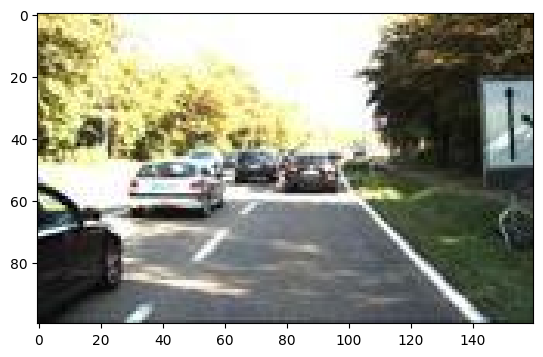

In [ ]:
import numpy as np

image = np.asarray(Image.open('./image-2.jpg'))
print(image.shape)
plot_one_image(image)

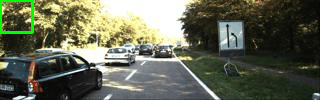

In [ ]:
show_sliding_window()

In [ ]:
new_image = image.copy()
print(new_image.shape)

In [ ]:
x = 20
y = 40
window_h = 32
window_w = 48

plot_one_image(new_image[y:y+window_h, x:x+window_w])

Sliding window code

In [ ]:
step_h = 16
step_w = 16
window_h = 32
window_w = 32

windows = []

for y in range(0,new_image.shape[0],step_h):
  for x in range(0,new_image.shape[1],step_w):
    window = new_image[y:y+window_h, x:x+window_w]
    if window.shape[0] == window_h and window.shape[1] == window_w:
      windows.append(window)

In [ ]:
labels = np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0])

Label: [0]


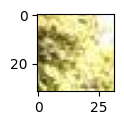

Label: [0]


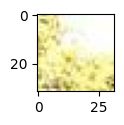

Label: [0]


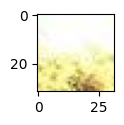

Label: [0]


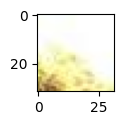

Label: [0]


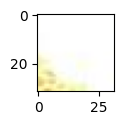

Label: [0]


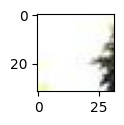

Label: [0]


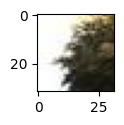

Label: [0]


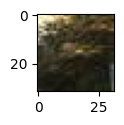

Label: [0]


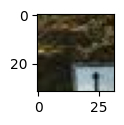

Label: [0]


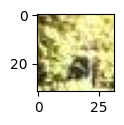

Label: [0]


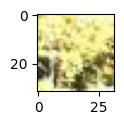

Label: [0]


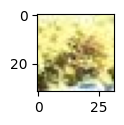

Label: [0]


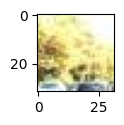

Label: [0]


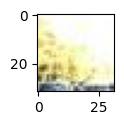

Label: [0]


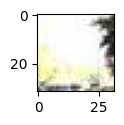

Label: [0]


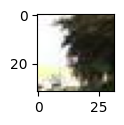

Label: [0]


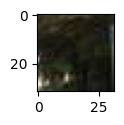

Label: [0]


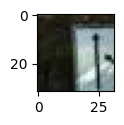

Label: [0]


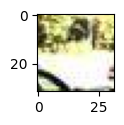

Label: [1]


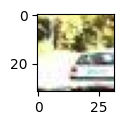

Label: [1]


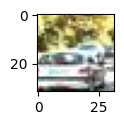

Label: [1]


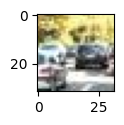

Label: [1]


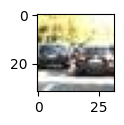

Label: [1]


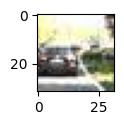

Label: [0]


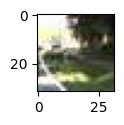

Label: [0]


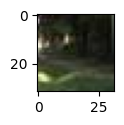

Label: [0]


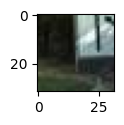

Label: [1]


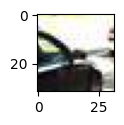

Label: [1]


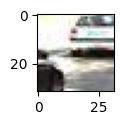

Label: [1]


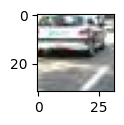

Label: [1]


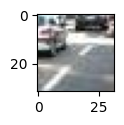

Label: [1]


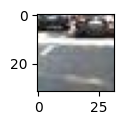

Label: [1]


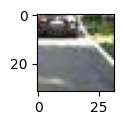

Label: [0]


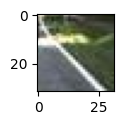

Label: [0]


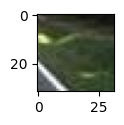

Label: [0]


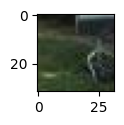

Label: [1]


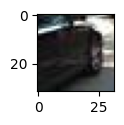

Label: [0]


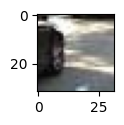

Label: [0]


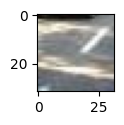

Label: [0]


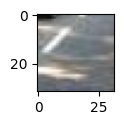

Label: [0]


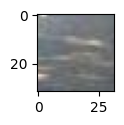

Label: [0]


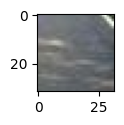

Label: [0]


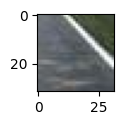

Label: [0]


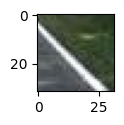

Label: [0]


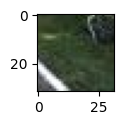

In [ ]:
for window, label in zip(windows, labels):
  plot_one_image(window, [label], fig_size=(1, 1))

In [ ]:
# tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# load data
(X_train, y_train), (X_test, y_test) = load_vehicle_dataset()

In [ ]:
# Build model
perceptron = Sequential()
perceptron.add(Flatten(input_shape = (32, 32, 3)))
perceptron.add(Dense(units = 128, activation = 'relu'))
perceptron.add(Dense(units = 3, activation = 'softmax'))

perceptron.compile(loss='categorical_crossentropy',
                   optimizer=optimizers.SGD(learning_rate=1e-3, momentum=0.9),
                   metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5841 - loss: 1.0089 - val_accuracy: 0.6687 - val_loss: 0.7807
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7249 - loss: 0.6666 - val_accuracy: 0.6987 - val_loss: 0.7227
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7635 - loss: 0.5932 - val_accuracy: 0.6883 - val_loss: 0.7272
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7883 - loss: 0.5434 - val_accuracy: 0.7053 - val_loss: 0.7033
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7981 - loss: 0.5048 - val_accuracy: 0.7173 - val_loss: 0.7113
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8220 - loss: 0.4646 - val_accuracy: 0.7120 - val_loss: 0.7306
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8382 - loss: 0.4253 - val_accuracy: 0.7030 - val_loss: 0.7504
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8492 - loss: 0.3857 - val_accuracy: 0.

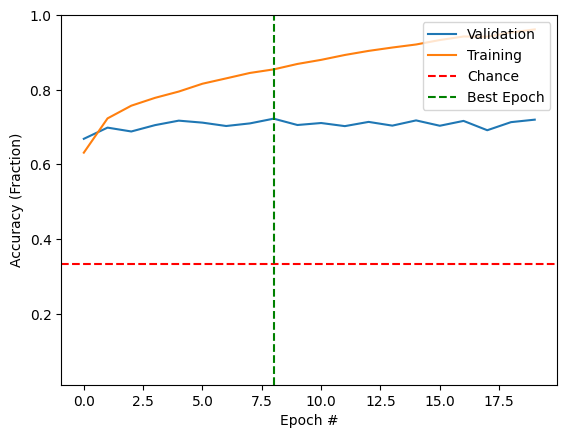

In [ ]:
monitor = ModelCheckpoint('./model.keras', monitor='val_loss', verbose=0, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)

y_train_onehot = label_to_onehot(y_train)
y_test_onehot = label_to_onehot(y_test)

# Train
history = perceptron.fit(X_train_norm, y_train_onehot, epochs=20, validation_data=(X_test_norm, y_test_onehot), shuffle=True, callbacks=[monitor])

plot_acc(history)

In [ ]:
normdata = normalize(windows)
pred = perceptron.predict(normdata)
print(pred)
y_pred = np.argmax(pred, axis = -1)
pred_prob = np.max(pred, axis = -1)

TypeError: unsupported operand type(s) for /: 'list' and 'int'